In [10]:
pip install tensorflow pandas numpy matplotlib seaborn scikit-learn opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.2 MB 5.2 MB/s eta 0:00:08
   - -------------------------------------- 1.8/40.2 MB 4.6 MB/s eta 0:00:09
   -- ------------------------------------- 2.6/40.2 MB 4.4 MB/s eta 0:00:09
   --- ------------------------------------ 3.4/40.2 MB 4.2 MB/s eta 0:00:09
   ---- ----------------------------------- 4.5/40.2 MB 4.1 MB/s eta 0:00:09
   ---- ----------------------------------- 5.0/40.2 MB 4.1 MB/s eta 0:00:09
   ----- ---------------------------------- 5.8/40.2 MB 4.0 MB/s eta 0:00:09
   ------ --------------------------------- 6.6/40.2 MB 4.0 MB/s eta 0:00:09
   ------- -------------------------------- 7.6/40.2 MB 4.0 MB/s eta 0:00:09
   -------- ------------------------------- 8.4/40.2 MB 4.0 MB/s eta 0:00:09
   -------- ------------------------------- 8.9/40.2 MB 3.9 MB/s eta 0:00:08
   --------- ------------------------------ 10.0/40.2 MB 3.9 MB/s eta 0:00:08
   --

In [11]:
#Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [12]:
# Set dataset path
DATASET_PATH = r"E:\UE class schedule\MACHINE LEARNING\Machine learning Assignment Submission II - Report\fashion-dataset"

IMAGE_FOLDER = os.path.join(DATASET_PATH, "fashion-dataset", "images")
CSV_PATH = os.path.join(DATASET_PATH, "fashion-dataset", "styles.csv")

In [18]:
# 2. Dataset loading

#Explanation:
#The dataset consists of fashion product images and a metadata file (styles.csv).
#The metadata file contains information about product categories, which will be used as class labels.

# DATASET_PATH
DATASET_PATH = r"E:\UE class schedule\MACHINE LEARNING\Machine learning Assignment Submission II - Report\fashion-dataset"

IMAGE_FOLDER = os.path.join(DATASET_PATH, "fashion-dataset", "images")
CSV_PATH = os.path.join(DATASET_PATH, "fashion-dataset", "styles.csv")

# Load metadata file
df = pd.read_csv(CSV_PATH, on_bad_lines="skip")
# Display first FOUR records
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [ ]:
# 3. Dataset preprocessing

#Explanation:
#Data preprocessing includes selecting relevant columns, creating image paths, removing missing images, and selecting the most common classes for classification.

df = df[['id', 'articleType']]

df['image'] = df['id'].astype(str) + ".jpg"
df['image_path'] = df['image'].apply(lambda x: os.path.join(IMAGE_FOLDER, x))

# Remove rows where image file does not exist
df = df[df['image_path'].apply(os.path.exists)]

# Select top 5 classes for easier training
top_classes = df['articleType'].value_counts().head(5).index
df = df[df['articleType'].isin(top_classes)]

print(df['articleType'].value_counts())
print("Total images:", len(df))

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [34]:
# 4. Train / Validation / Test Split/Data Cleaning 

#Explanation:
#The dataset is divided into training, validation, and testing sets to train the CNN model, tune its performance, and evaluate it on unseen images.
#Stratified sampling based on the articleType labels is used to ensure that each subset maintains a balanced distribution of fashion categories.

from sklearn.model_selection import train_test_split

# Remove missing values
df = df.dropna(subset=['articleType'])

# Check class distribution
print("Original Classes:")
print(df['articleType'].value_counts())

# Keep only top 5 most frequent classes
top_classes = df['articleType'].value_counts().head(5).index

df = df[df['articleType'].isin(top_classes)]

print("\nSelected Classes:")
print(df['articleType'].value_counts())

# Train/Test/Validation Split
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['articleType'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['articleType'],
    random_state=42
)

print("\nDataset Split Complete")
print("Training Images :", len(train_df))
print("Validation Images :", len(val_df))
print("Testing Images :", len(test_df))

print("\nTraining Class Distribution")
print(train_df['articleType'].value_counts())

Original Classes:
articleType
Tshirts         7066
Shirts          3215
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Name: count, dtype: int64

Selected Classes:
articleType
Tshirts         7066
Shirts          3215
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Name: count, dtype: int64

Dataset Split Complete
Training Images : 12392
Validation Images : 2656
Testing Images : 2656

Training Class Distribution
articleType
Tshirts         4946
Shirts          2250
Casual Shoes    1992
Watches         1779
Sports Shoes    1425
Name: count, dtype: int64


In [36]:
# 5. Image Resizing, Normalization, and Data Augmentation

#Explanation:
#Data augmentation is used to create slightly modified versions of training images by applying transformations such as rotation, zooming, shifting, and flipping.
#This helps the CNN model learn better patterns, reduces overfitting, and improves performance on unseen fashion images.

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image size and batch size
# All images will be resized to 128x128 pixels
IMG_SIZE = 128
BATCH_SIZE = 32

# Data augmentation is applied only to the training data
# rescale=1./255 normalizes pixel values from 0-255 to 0-1
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize image pixel values
    rotation_range=20,       # Randomly rotate images by 20 degrees
    zoom_range=0.2,          # Randomly zoom images
    horizontal_flip=True,    # Randomly flip images horizontally
    width_shift_range=0.1,   # Randomly shift images left or right
    height_shift_range=0.1   # Randomly shift images up or down
)

# Validation and test data should not be augmented
# Only normalization is applied for fair evaluation
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Create training image generator
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='articleType',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Create validation image generator
val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='articleType',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Create testing image generator
# shuffle=False keeps the order fixed for confusion matrix and classification report
test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='articleType',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Data augmentation and image generators created successfully.")

Found 12392 validated image filenames belonging to 5 classes.
Found 2656 validated image filenames belonging to 5 classes.
Found 2656 validated image filenames belonging to 5 classes.
Data augmentation and image generators created successfully.


In [38]:
# 6. CNN Model Development

#Explanation:
# A Convolutional Neural Network (CNN) is developed to automatically extract and learn visual features from fashion images.
# The model consists of convolutional layers for feature extraction, pooling layers for dimensionality reduction, batch normalization for training stability, and dense layers for final classification.)#

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

# Number of fashion categories
num_classes = len(train_generator.class_indices)

# Build CNN architecture
cnn_model = Sequential([

    # Input layer
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # First Convolution Block
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    BatchNormalization(),

    # Second Convolution Block
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    BatchNormalization(),

    # Third Convolution Block
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    BatchNormalization(),

    # Convert feature maps to a 1D vector
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Reduce overfitting
    Dropout(0.5),

    # Output Layer
    Dense(num_classes, activation='softmax')
])

# Compile model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 30, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,181 (12.61 MB)

 Trainable params: 3,305,733 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [40]:
# 7. Model Training

#Explanation:

# Train the custom CNN model
# train_generator provides augmented training images
# val_generator checks model performance on unseen validation images

history_cnn = cnn_model.fit(
    train_generator,              # Training data
    validation_data=val_generator, # Validation data
    epochs=10                     # Number of training cycles
)

# Display message after training is completed
print("CNN model training completed successfully.")

Epoch 1/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 379s 977ms/step - accuracy: 0.8165 - loss: 0.4388 - val_accuracy: 0.8957 - val_loss: 0.2587
Epoch 2/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 378s 974ms/step - accuracy: 0.8259 - loss: 0.4149 - val_accuracy: 0.6596 - val_loss: 2.2109
Epoch 3/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 361s 930ms/step - accuracy: 0.8375 - loss: 0.3989 - val_accuracy: 0.7843 - val_loss: 0.5941
Epoch 4/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 368s 948ms/step - accuracy: 0.8429 - loss: 0.3837 - val_accuracy: 0.7797 - val_loss: 0.8474
Epoch 5/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 380s 980ms/step - accuracy: 0.8536 - loss: 0.3619 - val_accuracy: 0.6329 - val_loss: 4.8666
Epoch 6/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 383s 988ms/step - accuracy: 0.8522 - loss: 0.3672 - val_accuracy: 0.8577 - val_loss: 0.3549
Epoch 7/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 377s 973ms/step - accuracy: 0.8544 - loss: 0.3528 - val_accuracy: 0.8517 - val_loss: 0.3657
Epoch 8/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 377s 971ms/step - accuracy: 0.8642 -

In [41]:
# 8. Model Evaluation
#Explanation:
#The trained CNN model is evaluated using the testing dataset to measure its performance on unseen images. 
#Test accuracy indicates how well the model classifies fashion products, while test loss represents the prediction error on the testing data.

# Evaluate the trained CNN model using the test datase
# The testing data contains unseen images that were not used
# during training or validation

test_loss, test_accuracy = cnn_model.evaluate(
    test_generator
)

# Display evaluation results
print("CNN Model Evaluation Results")
print("--------------------------------")
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("Test Loss:", round(test_loss, 4))

83/83 ━━━━━━━━━━━━━━━━━━━━ 64s 771ms/step - accuracy: 0.8302 - loss: 0.5609
CNN Model Evaluation Results
--------------------------------
Test Accuracy: 83.02 %
Test Loss: 0.5609


83/83 ━━━━━━━━━━━━━━━━━━━━ 54s 643ms/step


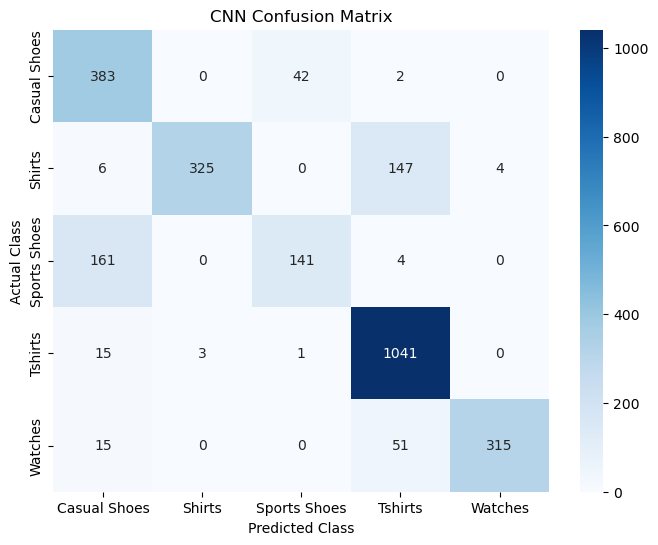

In [42]:
# 9. Confusion Matrix

#Explanation:
#The confusion matrix compares the actual and predicted class labels for the testing dataset.
#It helps identify correctly classified images and reveals which fashion categories are most frequently confused by the CNN model.
# Generate predictions for all images in the test dataset
# The model outputs probability scores for each class
y_pred = cnn_model.predict(test_generator)

# Convert probability scores into class labels
# The class with the highest probability is selected
y_pred_classes = np.argmax(y_pred, axis=1)

# Get the actual class labels from the test dataset
y_true = test_generator.classes

# Get class names for display in the confusion matrix
class_names = list(test_generator.class_indices.keys())

# Create confusion matrix
# Rows represent actual classes
# Columns represent predicted classes
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix using a heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,          # Display values inside cells
    fmt='d',             # Display as integers
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

# Add chart title and axis labels
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

# Save figure for report and presentation
plt.savefig('cnn_confusion_matrix.png', dpi=300)

# Display confusion matrix
plt.show()

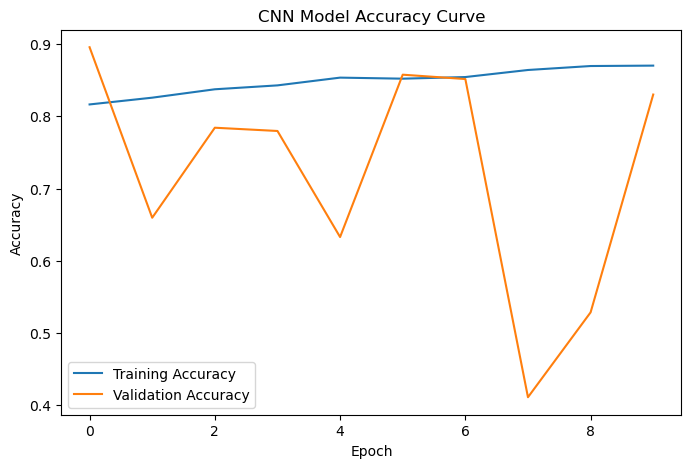

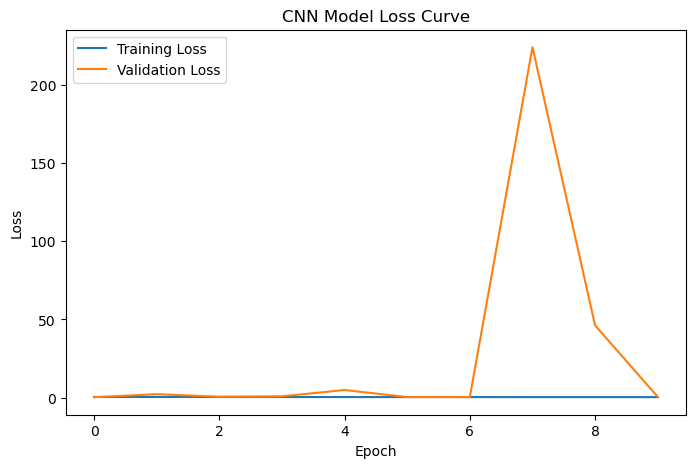

In [45]:
# 10. Accuracy and Loss Curves

#Explanation:
#The CNN model is evaluated using accuracy, precision, recall, and F1-score. 
#These metrics provide both overall and class-wise performance, helping to understand how well the model classifies different fashion product categories.

# Plot Training and Validation Accuracy

plt.figure(figsize=(8, 5))

# Training accuracy values
plt.plot(
    history_cnn.history['accuracy'],
    label='Training Accuracy'
)

# Validation accuracy values
plt.plot(
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)

# Add title and labels
plt.title('CNN Model Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Display legend
plt.legend()

# Save figure for report and presentation
plt.savefig('cnn_accuracy_curve.png', dpi=300)

# Display plot
plt.show()

# Plot Training and Validation Loss
plt.figure(figsize=(8, 5))

# Training loss values
plt.plot(
    history_cnn.history['loss'],
    label='Training Loss'
)

# Validation loss values
plt.plot(
    history_cnn.history['val_loss'],
    label='Validation Loss'
)

# Add title and labels
plt.title('CNN Model Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Display legend
plt.legend()

# Save figure for report and presentation
plt.savefig('cnn_loss_curve.png', dpi=300)

# Display plot
plt.show()

In [47]:
# 11. Classification Report

#Explanation:(#The classification report evaluates the performance of the CNN model for each fashion category using precision, recall, F1-score, and support. 
 #These metrics provide detailed insights into the strengths and weaknesses of the model across different classes.
from sklearn.metrics import classification_report
import pandas as pd

# Generate predictions for the test dataset
# The model returns probability values for each class
y_pred = cnn_model.predict(test_generator)

# Convert probabilities into predicted class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Get actual class labels
y_true = test_generator.classes

# Get class names from the generator
class_names = list(test_generator.class_indices.keys())

# Generate classification report
# Precision: Correct positive predictions
# Recall: Ability to identify all images of a class
# F1-score: Balance between precision and recall
# Support: Number of actual samples in each class
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
)

# Display classification report
print("Classification Report")
print("--------------------------------------")
print(report)

# Convert classification report into DataFrame
report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names,
        output_dict=True
    )
).transpose()

# Save report for project documentation
report_df.to_csv("classification_report.csv")

# Display report table
report_df

83/83 ━━━━━━━━━━━━━━━━━━━━ 54s 647ms/step
Classification Report
--------------------------------------
              precision    recall  f1-score   support

Casual Shoes       0.66      0.90      0.76       427
      Shirts       0.99      0.67      0.80       482
Sports Shoes       0.77      0.46      0.58       306
     Tshirts       0.84      0.98      0.90      1060
     Watches       0.99      0.83      0.90       381

    accuracy                           0.83      2656
   macro avg       0.85      0.77      0.79      2656
weighted avg       0.85      0.83      0.82      2656



,precision,recall,f1-score,support
Casual Shoes,0.660345,0.896956,0.760675,427.000000
Shirts,0.990854,0.674274,0.802469,482.000000
Sports Shoes,0.766304,0.460784,0.575510,306.000000
Tshirts,0.836145,0.982075,0.903254,1060.000000
Watches,0.987461,0.826772,0.900000,381.000000
accuracy,0.830196,0.830196,0.830196,0.830196
macro avg,0.848222,0.768172,0.788382,2656.000000
weighted avg,0.849617,0.830196,0.823815,2656.000000


In [48]:
# Convert classification report into DataFrame
report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names,
        output_dict=True
    )
).transpose()

# Save report for project documentation
report_df.to_csv("classification_report.csv")

# Display report table
report_df

,precision,recall,f1-score,support
Casual Shoes,0.660345,0.896956,0.760675,427.000000
Shirts,0.990854,0.674274,0.802469,482.000000
Sports Shoes,0.766304,0.460784,0.575510,306.000000
Tshirts,0.836145,0.982075,0.903254,1060.000000
Watches,0.987461,0.826772,0.900000,381.000000
accuracy,0.830196,0.830196,0.830196,0.830196
macro avg,0.848222,0.768172,0.788382,2656.000000
weighted avg,0.849617,0.830196,0.823815,2656.000000


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 805s 2s/step - accuracy: 0.8000 - loss: 0.5150 - val_accuracy: 0.9198 - val_loss: 0.2016
Epoch 2/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 882s 2s/step - accuracy: 0.9024 - loss: 0.2403 - val_accuracy: 0.9224 - val_loss: 0.1808
Epoch 3/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 874s 2s/step - accuracy: 0.9159 - loss: 0.2083 - val_accuracy: 0.9360 - val_loss: 0.1594
Epoch 4/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 871s 2s/step - accuracy: 0.9233 - loss: 0.1931 - val_accuracy: 0.9341 - val_loss: 0.1581
Epoch 5/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 895s 2s/step - accuracy: 0.9260 - loss: 0.1819 - val_accuracy: 0.9326 - val_loss: 0.1573
Epoch 6/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 886s 2s/step - accuracy: 0.9322 - loss: 0.1698 - val_accuracy: 0.9349 - val_loss: 0.1562
Epoch 7/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 886s 2s/step - accuracy: 0.9333 - loss: 0.1663 - val_accuracy: 0.9341 - val_loss: 0.1546
Epoch 8/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 872s 2s/step - accuracy: 0.9339 - loss: 0.1645 - val_accu

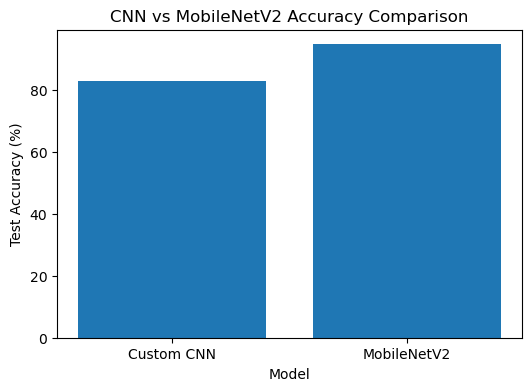


Transfer Learning Comparison Completed Successfully.


In [56]:
# 12. Comparison with Transfer Learning Model
# MobileNetV2 vs Custom CNN

# Explanation:
# Transfer learning uses a pre-trained deep learning model that has already
# learned useful image features from a large dataset. In this project,
# MobileNetV2 is used as a transfer learning model and its performance is
# compared with the custom CNN model using test accuracy and test loss.

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import pandas as pd
import matplotlib.pyplot as plt

# Load pre-trained MobileNetV2 model
# include_top=False removes the original ImageNet classification layer
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze all pre-trained layers
# This keeps previously learned features unchanged
base_model.trainable = False

# Add new layers for fashion classification
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(
    len(train_generator.class_indices),
    activation='softmax'
)(x)

# Create transfer learning model
transfer_model = Model(
    inputs=base_model.input,
    outputs=output
)

# Compile the model
transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
transfer_model.summary()

# Train Transfer Learning Model

history_transfer = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

print("MobileNetV2 training completed successfully.")

# Evaluate Transfer Learning Model

transfer_loss, transfer_accuracy = transfer_model.evaluate(
    test_generator
)

print("\nMobileNetV2 Test Accuracy:",
      round(transfer_accuracy * 100, 2), "%")

print("MobileNetV2 Test Loss:",
      round(transfer_loss, 4))

# Compare CNN and MobileNetV2

comparison_table = pd.DataFrame({

    'Model': [
        'Custom CNN',
        'MobileNetV2'
    ],

    'Test Accuracy (%)': [
        round(test_accuracy * 100, 2),
        round(transfer_accuracy * 100, 2)
    ],

    'Test Loss': [
        round(test_loss, 4),
        round(transfer_loss, 4)
    ]
})

print("\nModel Comparison Table")
print(comparison_table)

# Save comparison table
comparison_table.to_csv(
    "model_comparison_table.csv",
    index=False
)

# Create Comparison Chart

plt.figure(figsize=(6,4))

plt.bar(
    comparison_table['Model'],
    comparison_table['Test Accuracy (%)']
)

plt.title("CNN vs MobileNetV2 Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")

# Save figure for report
plt.savefig(
    "model_comparison_accuracy.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nTransfer Learning Comparison Completed Successfully.")

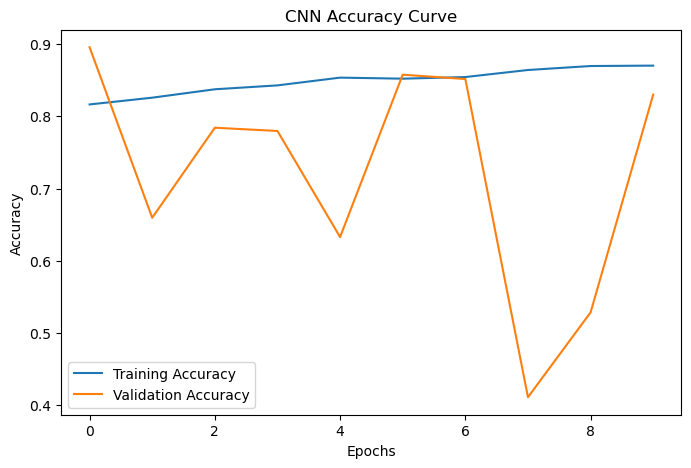

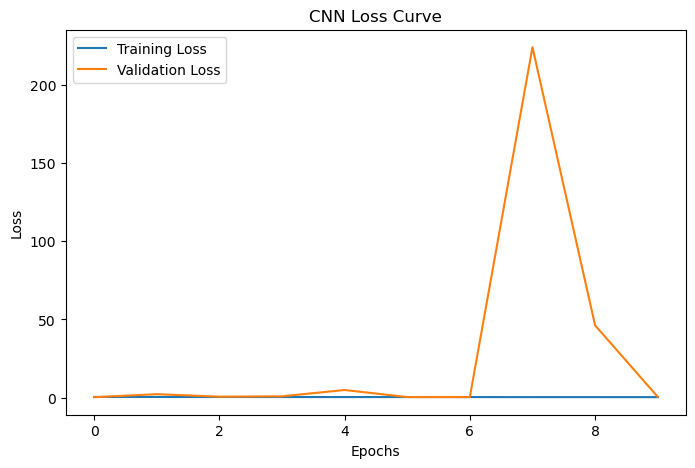

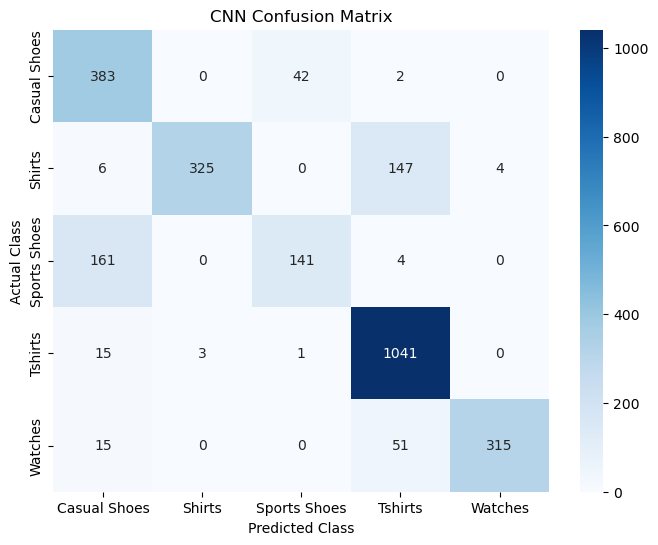

All important figures have been saved successfully.


In [55]:
# ==========================================
# 13. Saving Important Figures
# ==========================================

# Explanation:
# All important visualizations are saved as PNG files.
# These figures can be used directly in the final report,
# presentation slides, and project documentation.

# Save CNN Accuracy Curve
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('cnn_accuracy_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Save CNN Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig('cnn_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Save Confusion Matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.savefig(
    'cnn_confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("All important figures have been saved successfully.")

In [57]:
# ==========================================
# Evaluation Metrics
# ==========================================

# Explanation:
# This section evaluates the CNN model using accuracy, precision,
# recall, F1-score, and support. These metrics help measure both
# overall performance and class-wise classification performance.

from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import numpy as np

# Predict test images using the trained CNN model
y_pred = cnn_model.predict(test_generator)

# Convert predicted probability values into class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Get actual labels from the test generator
y_true = test_generator.classes

# Get class names
class_names = list(test_generator.class_indices.keys())

# Calculate overall accuracy
accuracy = accuracy_score(y_true, y_pred_classes)

print("Overall Test Accuracy:", round(accuracy * 100, 2), "%")

# Generate classification report
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
)

print("\nClassification Report:")
print(report)

# Save classification report as CSV
report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names,
        output_dict=True
    )
).transpose()

report_df.to_csv("cnn_evaluation_metrics.csv")

# Display table
report_df

83/83 ━━━━━━━━━━━━━━━━━━━━ 64s 762ms/step
Overall Test Accuracy: 83.02 %

Classification Report:
              precision    recall  f1-score   support

Casual Shoes       0.66      0.90      0.76       427
      Shirts       0.99      0.67      0.80       482
Sports Shoes       0.77      0.46      0.58       306
     Tshirts       0.84      0.98      0.90      1060
     Watches       0.99      0.83      0.90       381

    accuracy                           0.83      2656
   macro avg       0.85      0.77      0.79      2656
weighted avg       0.85      0.83      0.82      2656



,precision,recall,f1-score,support
Casual Shoes,0.660345,0.896956,0.760675,427.000000
Shirts,0.990854,0.674274,0.802469,482.000000
Sports Shoes,0.766304,0.460784,0.575510,306.000000
Tshirts,0.836145,0.982075,0.903254,1060.000000
Watches,0.987461,0.826772,0.900000,381.000000
accuracy,0.830196,0.830196,0.830196,0.830196
macro avg,0.848222,0.768172,0.788382,2656.000000
weighted avg,0.849617,0.830196,0.823815,2656.000000
